In [1]:
!pip install -q zarr

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.6 MB/s eta 0:00:00


In [2]:
base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"

zarr_path = base / "train" / f"{sample_id}.zarr"
geff_path = base / "train" / f"{sample_id}.geff"

if not base.exists():
    raise FileNotFoundError(
        "Attach the Biohub Cell Tracking During Development competition data."
    )

image = zarr.open(zarr_path, mode="r")["0"]
geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [3]:
def first_existing_array(group, paths):
    for path in paths:
        try:
            return np.asarray(group[path][:]), path
        except Exception:
            continue
    return None, None


def load_geff_edges(group):
    source_paths = [
        "edges/source",
        "edges/sources",
        "edges/source_ids",
        "edges/props/source/values",
        "edges/props/source_id/values",
    ]

    target_paths = [
        "edges/target",
        "edges/targets",
        "edges/target_ids",
        "edges/props/target/values",
        "edges/props/target_id/values",
    ]

    sources, source_path = first_existing_array(group, source_paths)
    targets, target_path = first_existing_array(group, target_paths)

    if sources is not None and targets is not None:
        print("Edge source path:", source_path)
        print("Edge target path:", target_path)
        return pd.DataFrame({
            "source": sources,
            "target": targets,
        })

    for path in [
        "edges/ids",
        "edges/index",
        "edges/indices",
        "edges/endpoints",
    ]:
        try:
            arr = np.asarray(group[path][:])

            if arr.ndim == 2 and arr.shape[1] == 2:
                return pd.DataFrame(arr, columns=["source", "target"])

            if arr.ndim == 2 and arr.shape[0] == 2:
                return pd.DataFrame({
                    "source": arr[0],
                    "target": arr[1],
                })

        except Exception:
            continue

    raise KeyError("Could not identify GEFF edge arrays.")


edges_df = load_geff_edges(geff)

source_nodes = nodes_df.rename(columns={
    "node_id": "source",
    "t": "source_t",
    "z": "source_z",
    "y": "source_y",
    "x": "source_x",
})

target_nodes = nodes_df.rename(columns={
    "node_id": "target",
    "t": "target_t",
    "z": "target_z",
    "y": "target_y",
    "x": "target_x",
})

edge_detail_df = (
    edges_df
    .merge(source_nodes, on="source", how="left")
    .merge(target_nodes, on="target", how="left")
)

edge_detail_df["time_gap"] = (
    edge_detail_df["target_t"] -
    edge_detail_df["source_t"]
)

consecutive_edges_df = (
    edge_detail_df[edge_detail_df["time_gap"] == 1]
    .copy()
    .reset_index(drop=True)
)

print("GT edges:", len(edges_df))
print("Consecutive GT edges:", len(consecutive_edges_df))


GT edges: 773
Consecutive GT edges: 773


In [4]:
def pairwise_distances_3d(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)
    return cdist(a, b)


def extract_patch_3d(volume, z, y, x, rz=2, ryx=4):
    z0 = max(0, z - rz)
    z1 = min(volume.shape[0], z + rz + 1)
    y0 = max(0, y - ryx)
    y1 = min(volume.shape[1], y + ryx + 1)
    x0 = max(0, x - ryx)
    x1 = min(volume.shape[2], x + ryx + 1)

    patch = volume[z0:z1, y0:y1, x0:x1]

    return patch, (z0, z1, y0, y1, x0, x1)


In [5]:
def compute_2d_candidate_features(frame_3d, candidate_df, patch_radius=4):
    rows = []

    for _, r in candidate_df.iterrows():
        z = int(r["z"])
        y = int(r["y"])
        x = int(r["x"])
        sigma = float(r["sigma"])

        y0 = max(0, y - patch_radius)
        y1 = min(frame_3d.shape[1], y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(frame_3d.shape[2], x + patch_radius + 1)

        patch = frame_3d[z, y0:y1, x0:x1]

        if patch.size == 0:
            continue

        center_intensity = float(frame_3d[z, y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = float(patch_max - patch_mean)

        peak_y, peak_x = np.unravel_index(np.argmax(patch), patch.shape)
        center_y = (patch.shape[0] - 1) / 2.0
        center_x = (patch.shape[1] - 1) / 2.0

        center_to_patch_max_dist = float(np.sqrt(
            (peak_y - center_y) ** 2 +
            (peak_x - center_x) ** 2
        ))

        yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)

        if mass.sum() > 0:
            com_y = (yy * mass).sum() / mass.sum()
            com_x = (xx * mass).sum() / mass.sum()

            patch_com_offset = float(np.sqrt(
                (com_y - center_y) ** 2 +
                (com_x - center_x) ** 2
            ))
        else:
            patch_com_offset = 0.0

        is_near_border = int(
            (z <= 1) or
            (z >= frame_3d.shape[0] - 2) or
            (y <= patch_radius) or
            (y >= frame_3d.shape[1] - patch_radius - 1) or
            (x <= patch_radius) or
            (x >= frame_3d.shape[2] - patch_radius - 1)
        )

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": sigma,
            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
        })

    return pd.DataFrame(rows)


In [6]:
def compute_3d_candidate_features(frame_3d, candidate_df, rz=2, ryx=4):
    rows = []

    for _, r in candidate_df.iterrows():
        z = int(r["z"])
        y = int(r["y"])
        x = int(r["x"])

        patch, bounds = extract_patch_3d(
            frame_3d,
            z,
            y,
            x,
            rz=rz,
            ryx=ryx,
        )

        z0, z1, y0, y1, x0, x1 = bounds

        if patch.size == 0:
            continue

        local_z = z - z0
        local_y = y - y0
        local_x = x - x0

        center_voxel = float(patch[local_z, local_y, local_x])

        vol_mean = float(patch.mean())
        vol_std = float(patch.std())
        vol_max = float(patch.max())

        z_line = patch[:, local_y, local_x]
        z_line_mean = float(z_line.mean())
        z_line_std = float(z_line.std())
        z_line_max = float(z_line.max())

        center_over_vol_mean = float(
            center_voxel / (vol_mean + 1e-6)
        )

        center_minus_vol_mean = float(
            center_voxel - vol_mean
        )

        neighbor_slices = []

        if local_z - 1 >= 0:
            neighbor_slices.append(patch[local_z - 1])

        if local_z + 1 < patch.shape[0]:
            neighbor_slices.append(patch[local_z + 1])

        if neighbor_slices:
            neighbor_mean = float(
                np.mean([s.mean() for s in neighbor_slices])
            )
        else:
            neighbor_mean = vol_mean

        center_slice_minus_neighbor_mean = float(
            patch[local_z].mean() - neighbor_mean
        )

        slice_mean_std = float(
            np.std([s.mean() for s in patch])
        )

        peak_z, _, _ = np.unravel_index(
            np.argmax(patch),
            patch.shape,
        )

        z_peak_offset = int(
            abs(peak_z - local_z)
        )

        zz, yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)

        if mass.sum() > 0:
            com_z = (zz * mass).sum() / mass.sum()
            com_y = (yy * mass).sum() / mass.sum()
            com_x = (xx * mass).sum() / mass.sum()

            mass_center_offset_3d = float(np.sqrt(
                (com_z - local_z) ** 2 +
                (com_y - local_y) ** 2 +
                (com_x - local_x) ** 2
            ))
        else:
            mass_center_offset_3d = 0.0

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "center_voxel": center_voxel,
            "vol_mean": vol_mean,
            "vol_std": vol_std,
            "vol_max": vol_max,
            "z_line_mean": z_line_mean,
            "z_line_std": z_line_std,
            "z_line_max": z_line_max,
            "center_over_vol_mean": center_over_vol_mean,
            "center_minus_vol_mean": center_minus_vol_mean,
            "center_slice_minus_neighbor_mean": center_slice_minus_neighbor_mean,
            "slice_mean_std": slice_mean_std,
            "z_peak_offset": z_peak_offset,
            "mass_center_offset_3d": mass_center_offset_3d,
            "peak_to_mean_ratio": float(
                vol_max / (vol_mean + 1e-6)
            ),
            "bright_fraction": float(
                (patch > vol_mean).mean()
            ),
        })

    return pd.DataFrame(rows)


In [7]:
def detect_slice_wise_log(frame_3d, log_kwargs):
    rows = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        slice_min = float(slice_2d.min())
        slice_max = float(slice_2d.max())

        if slice_max <= slice_min:
            continue

        slice_norm = (
            (slice_2d - slice_min) /
            (slice_max - slice_min)
        )

        blobs = blob_log(
            slice_norm,
            min_sigma=log_kwargs.get("min_sigma", 2.5),
            max_sigma=log_kwargs.get("max_sigma", 3.5),
            num_sigma=log_kwargs.get("num_sigma", 3),
            threshold=log_kwargs.get("threshold", 0.15),
        )

        for y, x, sigma in blobs:
            y = int(np.clip(
                round(y),
                0,
                frame_3d.shape[1] - 1,
            ))

            x = int(np.clip(
                round(x),
                0,
                frame_3d.shape[2] - 1,
            ))

            rows.append({
                "z": int(z),
                "y": y,
                "x": x,
                "sigma": float(sigma),
                "nms_score": float(frame_3d[z, y, x]),
            })

    if not rows:
        return pd.DataFrame(
            columns=["z", "y", "x", "sigma", "nms_score"]
        )

    return (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["z", "y", "x"])
        .reset_index(drop=True)
    )


def greedy_3d_nms(candidate_df, nms_radius=3.0):
    if len(candidate_df) == 0:
        return candidate_df.copy()

    work_df = (
        candidate_df
        .sort_values("nms_score", ascending=False)
        .reset_index(drop=True)
    )

    kept_rows = []

    while len(work_df) > 0:
        keep_row = work_df.iloc[0].copy()
        kept_rows.append(keep_row)

        keep_point = np.array(
            [
                keep_row["z"],
                keep_row["y"],
                keep_row["x"],
            ],
            dtype=float,
        )

        points = work_df[
            ["z", "y", "x"]
        ].to_numpy(dtype=float)

        distances = np.sqrt(
            ((points - keep_point) ** 2).sum(axis=1)
        )

        work_df = (
            work_df[distances > nms_radius]
            .reset_index(drop=True)
        )

    return pd.DataFrame(kept_rows).reset_index(drop=True)


def build_candidate_feature_table(
    image,
    t,
    log_kwargs,
    nms_radius=3.0,
):
    frame_3d = np.asarray(image[t])

    raw_df = detect_slice_wise_log(
        frame_3d,
        log_kwargs=log_kwargs,
    )

    nms_df = greedy_3d_nms(
        raw_df,
        nms_radius=nms_radius,
    )

    if len(nms_df) == 0:
        return pd.DataFrame(), frame_3d, raw_df

    features_2d = compute_2d_candidate_features(
        frame_3d,
        nms_df[["z", "y", "x", "sigma"]].copy(),
        patch_radius=4,
    )

    features_3d = compute_3d_candidate_features(
        frame_3d,
        nms_df[["z", "y", "x"]].copy(),
        rz=2,
        ryx=4,
    )

    candidate_df = nms_df.merge(
        features_2d,
        on=["z", "y", "x"],
        how="left",
        suffixes=("", "_2d"),
    )

    candidate_df = candidate_df.merge(
        features_3d,
        on=["z", "y", "x"],
        how="left",
        suffixes=("", "_3d"),
    )

    candidate_df = candidate_df.drop(
        columns=["nms_score"],
        errors="ignore",
    )

    candidate_df["t"] = t

    return candidate_df, frame_3d, raw_df


In [8]:
train_timesteps = [0, 8, 20, 40]

nms_radius = 3.0
distance_clip = 20.0

log_kwargs = {
    "min_sigma": 2.5,
    "max_sigma": 3.5,
    "num_sigma": 3,
    "threshold": 0.15,
}

feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "center_voxel",
    "vol_mean",
    "vol_std",
    "vol_max",
    "z_line_mean",
    "z_line_std",
    "z_line_max",
    "center_over_vol_mean",
    "center_minus_vol_mean",
    "center_slice_minus_neighbor_mean",
    "slice_mean_std",
    "z_peak_offset",
    "mass_center_offset_3d",
    "peak_to_mean_ratio",
    "bright_fraction",
]


In [9]:
train_tables = []

for t in train_timesteps:
    candidate_df_t, frame_3d, raw_df_t = (
        build_candidate_feature_table(
            image=image,
            t=t,
            log_kwargs=log_kwargs,
            nms_radius=nms_radius,
        )
    )

    if len(candidate_df_t) == 0:
        continue

    gt_t = nodes_df[
        nodes_df["t"] == t
    ].copy()

    gt_points = gt_t[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    candidate_points = candidate_df_t[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    candidate_df_t["nearest_gt_dist"] = (
        pairwise_distances_3d(
            gt_points,
            candidate_points,
        ).min(axis=0)
        if len(gt_points) > 0
        else np.inf
    )

    candidate_df_t["target_dist"] = (
        candidate_df_t["nearest_gt_dist"]
        .clip(lower=0, upper=distance_clip)
    )

    train_tables.append(candidate_df_t)

    print(
        f"t={t}: raw={len(raw_df_t)}, "
        f"nms={len(candidate_df_t)}"
    )

train_df = pd.concat(
    train_tables,
    ignore_index=True,
)

distance_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

distance_model.fit(
    train_df[feature_cols].fillna(0.0),
    train_df["target_dist"],
)

print("Training rows:", len(train_df))


t=0: raw=1541, nms=670
t=8: raw=1478, nms=661
t=20: raw=1653, nms=695
t=40: raw=1596, nms=688
Training rows: 2714


In [10]:
def run_final_candidate_detector(
    image,
    t,
    model,
    feature_cols,
    log_kwargs,
    nms_radius=3.0,
    top_k=200,
):
    candidate_df, frame_3d, raw_df = (
        build_candidate_feature_table(
            image=image,
            t=t,
            log_kwargs=log_kwargs,
            nms_radius=nms_radius,
        )
    )

    if len(candidate_df) == 0:
        empty = pd.DataFrame(
            columns=[
                "t",
                "node_id",
                "rank_position",
                "z",
                "y",
                "x",
                "sigma",
                "pred_dist",
            ]
        )

        return {
            "raw_candidates": raw_df,
            "ranked_candidates": empty,
            "selected_candidates": empty.copy(),
            "frame_3d": frame_3d,
        }

    ranked_df = candidate_df.copy()

    ranked_df["pred_dist"] = model.predict(
        ranked_df[feature_cols].fillna(0.0)
    )

    ranked_df = (
        ranked_df
        .sort_values("pred_dist", ascending=True)
        .reset_index(drop=True)
    )

    ranked_df["rank_position"] = (
        np.arange(1, len(ranked_df) + 1)
    )

    ranked_df["node_id"] = [
        f"pred_t{t}_{i}"
        for i in range(len(ranked_df))
    ]

    selected_df = (
        ranked_df
        .head(min(top_k, len(ranked_df)))
        .copy()
    )

    return {
        "raw_candidates": raw_df,
        "ranked_candidates": ranked_df,
        "selected_candidates": selected_df,
        "frame_3d": frame_3d,
    }


In [11]:
start_t = 0
end_t = 20
top_k = 200
max_movement = 10.0

all_detection_tables = []
detector_outputs = {}

for t in range(start_t, end_t + 1):
    output = run_final_candidate_detector(
        image=image,
        t=t,
        model=distance_model,
        feature_cols=feature_cols,
        log_kwargs=log_kwargs,
        nms_radius=nms_radius,
        top_k=top_k,
    )

    detector_outputs[t] = output

    selected_t = (
        output["selected_candidates"]
        .copy()
    )

    all_detection_tables.append(selected_t)

    print(
        f"t={t}: "
        f"raw={len(output['raw_candidates'])}, "
        f"ranked={len(output['ranked_candidates'])}, "
        f"selected={len(selected_t)}"
    )

all_detections_df = pd.concat(
    all_detection_tables,
    ignore_index=True,
)

print("Total selected detections:", len(all_detections_df))
display(all_detections_df[
    [
        "t",
        "node_id",
        "rank_position",
        "z",
        "y",
        "x",
        "pred_dist",
    ]
].head())


t=0: raw=1541, ranked=670, selected=200
t=1: raw=1530, ranked=651, selected=200
t=2: raw=1687, ranked=706, selected=200
t=3: raw=1540, ranked=656, selected=200
t=4: raw=1555, ranked=658, selected=200
t=5: raw=1461, ranked=606, selected=200
t=6: raw=1355, ranked=585, selected=200
t=7: raw=1365, ranked=598, selected=200
t=8: raw=1478, ranked=661, selected=200
t=9: raw=1619, ranked=679, selected=200
t=10: raw=1639, ranked=687, selected=200
t=11: raw=1655, ranked=702, selected=200
t=12: raw=1556, ranked=662, selected=200
t=13: raw=1519, ranked=664, selected=200
t=14: raw=1609, ranked=693, selected=200
t=15: raw=1641, ranked=711, selected=200
t=16: raw=1651, ranked=697, selected=200
t=17: raw=1674, ranked=716, selected=200
t=18: raw=1675, ranked=730, selected=200
t=19: raw=1667, ranked=716, selected=200
t=20: raw=1653, ranked=695, selected=200
Total selected detections: 4200


,t,node_id,rank_position,z,y,x,pred_dist
0,0,pred_t0_0,1,24.0,189.0,56.0,15.303363
1,0,pred_t0_1,2,27.0,212.0,110.0,15.671573
2,0,pred_t0_2,3,7.0,241.0,51.0,15.697220
3,0,pred_t0_3,4,44.0,127.0,127.0,15.798581
4,0,pred_t0_4,5,22.0,208.0,55.0,16.286263


In [12]:
def link_greedy_one_to_one(
    source_df,
    target_df,
    max_movement=np.inf,
):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(
            columns=[
                "source",
                "target",
                "distance",
            ]
        )

    source_points = source_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    target_points = target_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    dist = cdist(
        source_points,
        target_points,
    )

    source_idx, target_idx = np.indices(
        dist.shape
    )

    pair_df = pd.DataFrame({
        "source_index": source_idx.ravel(),
        "target_index": target_idx.ravel(),
        "distance": dist.ravel(),
    })

    pair_df = (
        pair_df[
            pair_df["distance"] <= max_movement
        ]
        .sort_values("distance")
        .reset_index(drop=True)
    )

    used_sources = set()
    used_targets = set()
    rows = []

    for _, row in pair_df.iterrows():
        source_index = int(row["source_index"])
        target_index = int(row["target_index"])

        if source_index in used_sources:
            continue

        if target_index in used_targets:
            continue

        used_sources.add(source_index)
        used_targets.add(target_index)

        rows.append({
            "source": source_df.iloc[
                source_index
            ]["node_id"],

            "target": target_df.iloc[
                target_index
            ]["node_id"],

            "distance": float(
                row["distance"]
            ),
        })

    return pd.DataFrame(rows)


In [13]:
all_link_tables = []

for source_t in range(start_t, end_t):
    target_t = source_t + 1

    source_df = (
        all_detections_df[
            all_detections_df["t"] == source_t
        ]
        .copy()
        .reset_index(drop=True)
    )

    target_df = (
        all_detections_df[
            all_detections_df["t"] == target_t
        ]
        .copy()
        .reset_index(drop=True)
    )

    links_t = link_greedy_one_to_one(
        source_df=source_df,
        target_df=target_df,
        max_movement=max_movement,
    )

    links_t["source_t"] = source_t
    links_t["target_t"] = target_t

    all_link_tables.append(links_t)

    print(
        f"{source_t}->{target_t}: "
        f"links={len(links_t)}"
    )

all_links_df = pd.concat(
    all_link_tables,
    ignore_index=True,
)

print("Total predicted links:", len(all_links_df))
display(all_links_df.head())


0->1: links=98
1->2: links=99
2->3: links=92
3->4: links=99
4->5: links=99
5->6: links=109
6->7: links=107
7->8: links=95
8->9: links=97
9->10: links=100
10->11: links=101
11->12: links=85
12->13: links=93
13->14: links=96
14->15: links=92
15->16: links=99
16->17: links=83
17->18: links=99
18->19: links=90
19->20: links=90
Total predicted links: 1923


,source,target,distance,source_t,target_t
0,pred_t0_3,pred_t1_27,1.0,0,1
1,pred_t0_31,pred_t1_104,1.0,0,1
2,pred_t0_45,pred_t1_71,1.0,0,1
3,pred_t0_53,pred_t1_86,1.0,0,1
4,pred_t0_98,pred_t1_102,1.0,0,1


In [14]:
def build_tracks_from_links(
    detections_df,
    links_df,
):
    detections = (
        detections_df
        .sort_values(
            ["t", "rank_position"]
        )
        .copy()
        .reset_index(drop=True)
    )

    incoming_source = {
        row["target"]: row["source"]
        for _, row in links_df.iterrows()
    }

    outgoing_target = {
        row["source"]: row["target"]
        for _, row in links_df.iterrows()
    }

    track_id_by_node = {}
    next_track_id = 0

    for _, row in detections.iterrows():
        node_id = row["node_id"]

        if node_id in incoming_source:
            parent_id = incoming_source[node_id]

            if parent_id in track_id_by_node:
                track_id_by_node[node_id] = (
                    track_id_by_node[parent_id]
                )
                continue

        track_id_by_node[node_id] = next_track_id
        next_track_id += 1

    tracks_df = detections.copy()

    tracks_df["track_id"] = tracks_df[
        "node_id"
    ].map(track_id_by_node)

    tracks_df["parent_node_id"] = tracks_df[
        "node_id"
    ].map(incoming_source)

    tracks_df["child_node_id"] = tracks_df[
        "node_id"
    ].map(outgoing_target)

    return tracks_df


tracks_df = build_tracks_from_links(
    detections_df=all_detections_df,
    links_df=all_links_df,
)

print("Predicted tracks:", tracks_df["track_id"].nunique())
display(tracks_df[
    [
        "track_id",
        "t",
        "node_id",
        "parent_node_id",
        "child_node_id",
        "z",
        "y",
        "x",
    ]
].head(20))


Predicted tracks: 2277


,track_id,t,node_id,parent_node_id,child_node_id,z,y,x
0,0,0,pred_t0_0,NaN,pred_t1_35,24.0,189.0,56.0
1,1,0,pred_t0_1,NaN,NaN,27.0,212.0,110.0
2,2,0,pred_t0_2,NaN,pred_t1_46,7.0,241.0,51.0
3,3,0,pred_t0_3,NaN,pred_t1_27,44.0,127.0,127.0
4,4,0,pred_t0_4,NaN,pred_t1_115,22.0,208.0,55.0
5,5,0,pred_t0_5,NaN,NaN,47.0,125.0,129.0
6,6,0,pred_t0_6,NaN,NaN,25.0,211.0,55.0
7,7,0,pred_t0_7,NaN,pred_t1_8,41.0,204.0,94.0
8,8,0,pred_t0_8,NaN,pred_t1_111,35.0,61.0,186.0
9,9,0,pred_t0_9,NaN,pred_t1_89,15.0,191.0,52.0


In [15]:
track_summary_df = (
    tracks_df
    .groupby("track_id", as_index=False)
    .agg(
        start_t=("t", "min"),
        end_t=("t", "max"),
        num_detections=("node_id", "count"),
        mean_pred_dist=("pred_dist", "mean"),
        mean_rank=("rank_position", "mean"),
    )
)

track_summary_df["duration"] = (
    track_summary_df["end_t"] -
    track_summary_df["start_t"] +
    1
)

track_summary_df = (
    track_summary_df
    .sort_values(
        ["duration", "num_detections"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(track_summary_df.head(30))


,track_id,start_t,end_t,num_detections,mean_pred_dist,mean_rank,duration
0,343,2,14,13,18.525207,64.846154,13
1,76,0,11,12,18.814187,83.333333,12
2,340,2,12,11,18.662108,87.636364,11
3,1124,10,20,11,18.760266,101.181818,11
4,67,0,9,10,19.014827,123.000000,10
5,147,0,9,10,18.722172,73.600000,10
6,809,7,16,10,18.789064,99.200000,10
7,920,8,17,10,18.591059,68.500000,10
8,1208,11,20,10,18.114167,51.900000,10
9,24,0,8,9,18.485015,43.555556,9


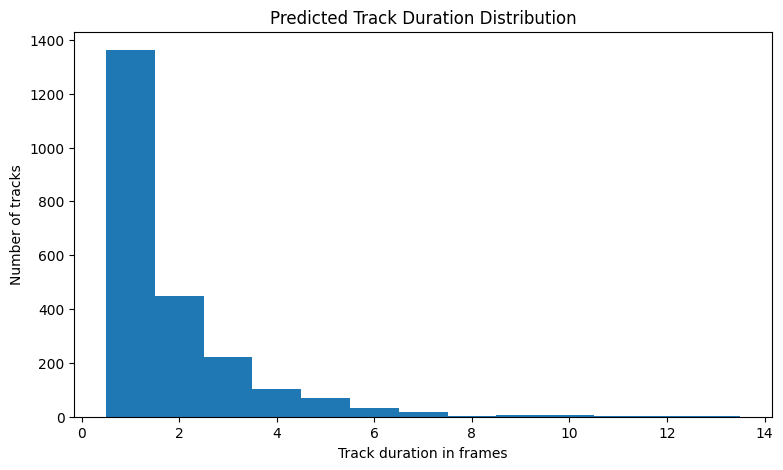

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(
    track_summary_df["duration"],
    bins=np.arange(
        1,
        track_summary_df["duration"].max() + 2,
    ) - 0.5,
)

plt.title("Predicted Track Duration Distribution")
plt.xlabel("Track duration in frames")
plt.ylabel("Number of tracks")
plt.show()


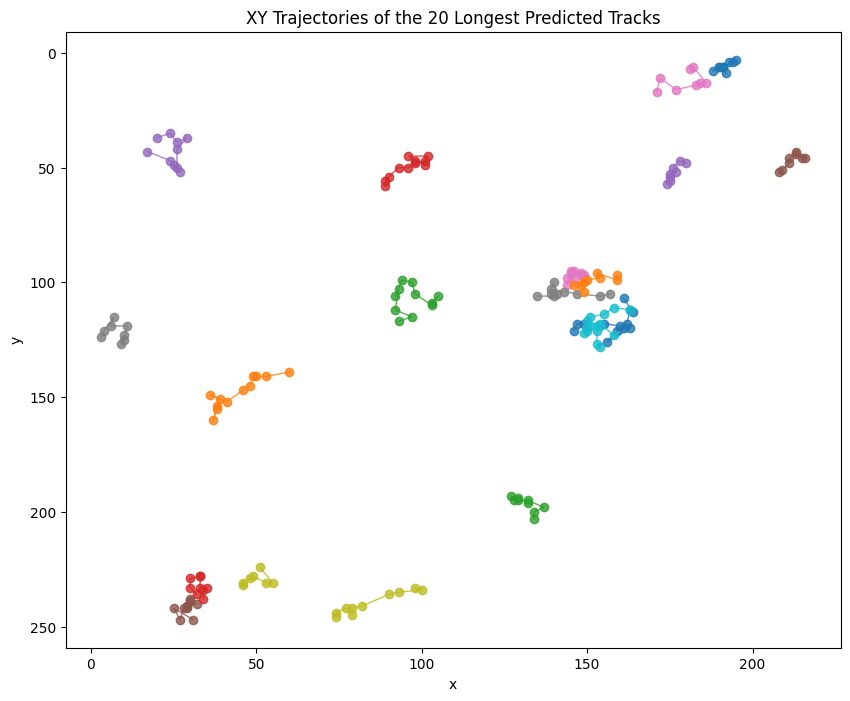

In [17]:
top_track_ids = (
    track_summary_df
    .head(20)["track_id"]
    .tolist()
)

plt.figure(figsize=(10, 8))

for track_id in top_track_ids:
    track = (
        tracks_df[
            tracks_df["track_id"] == track_id
        ]
        .sort_values("t")
    )

    plt.plot(
        track["x"],
        track["y"],
        marker="o",
        linewidth=1,
        alpha=0.8,
    )

plt.gca().invert_yaxis()
plt.title("XY Trajectories of the 20 Longest Predicted Tracks")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [18]:
def get_true_consecutive_edges_for_range(
    consecutive_edges_df,
    start_t,
    end_t,
):
    return consecutive_edges_df[
        (consecutive_edges_df["source_t"] >= start_t) &
        (consecutive_edges_df["target_t"] <= end_t)
    ].copy()


true_edges_range_df = (
    get_true_consecutive_edges_for_range(
        consecutive_edges_df,
        start_t=start_t,
        end_t=end_t,
    )
)

print("True GT links in range:", len(true_edges_range_df))


True GT links in range: 195


In [19]:
def match_predicted_nodes_to_gt(
    predicted_df,
    gt_df,
    match_radius=6.0,
):
    match_rows = []

    for t in sorted(predicted_df["t"].unique()):
        pred_t = (
            predicted_df[
                predicted_df["t"] == t
            ]
            .copy()
            .reset_index(drop=True)
        )

        gt_t = (
            gt_df[
                gt_df["t"] == t
            ]
            .copy()
            .reset_index(drop=True)
        )

        if len(pred_t) == 0 or len(gt_t) == 0:
            continue

        pred_points = pred_t[
            ["z", "y", "x"]
        ].to_numpy(dtype=float)

        gt_points = gt_t[
            ["z", "y", "x"]
        ].to_numpy(dtype=float)

        dist = cdist(
            pred_points,
            gt_points,
        )

        pred_idx, gt_idx = np.indices(
            dist.shape
        )

        pairs = pd.DataFrame({
            "pred_index": pred_idx.ravel(),
            "gt_index": gt_idx.ravel(),
            "distance": dist.ravel(),
        })

        pairs = (
            pairs[
                pairs["distance"] <= match_radius
            ]
            .sort_values("distance")
            .reset_index(drop=True)
        )

        used_pred = set()
        used_gt = set()

        for _, row in pairs.iterrows():
            p_idx = int(row["pred_index"])
            g_idx = int(row["gt_index"])

            if p_idx in used_pred or g_idx in used_gt:
                continue

            used_pred.add(p_idx)
            used_gt.add(g_idx)

            match_rows.append({
                "t": t,
                "pred_node_id": pred_t.iloc[p_idx]["node_id"],
                "gt_node_id": gt_t.iloc[g_idx]["node_id"],
                "match_distance": float(row["distance"]),
            })

    return pd.DataFrame(match_rows)


node_matches_df = match_predicted_nodes_to_gt(
    predicted_df=all_detections_df,
    gt_df=nodes_df,
    match_radius=6.0,
)

print("Matched predicted nodes:", len(node_matches_df))
display(node_matches_df.head())


Matched predicted nodes: 87


,t,pred_node_id,gt_node_id,match_distance
0,0,pred_t0_4,1.060000e+11,1.000000
1,0,pred_t0_1,1.060000e+11,1.414214
2,0,pred_t0_11,1.060000e+11,2.828427
3,0,pred_t0_8,1.060000e+11,3.000000
4,0,pred_t0_9,1.060000e+11,4.242641


In [20]:
pred_to_gt = dict(
    zip(
        node_matches_df["pred_node_id"],
        node_matches_df["gt_node_id"],
    )
)

evaluated_pred_links = all_links_df.copy()

evaluated_pred_links["matched_source_gt"] = (
    evaluated_pred_links["source"]
    .map(pred_to_gt)
)

evaluated_pred_links["matched_target_gt"] = (
    evaluated_pred_links["target"]
    .map(pred_to_gt)
)

true_gt_pairs = set(
    map(
        tuple,
        true_edges_range_df[
            ["source", "target"]
        ].to_numpy(),
    )
)

evaluated_pred_links["both_nodes_matched"] = (
    evaluated_pred_links["matched_source_gt"].notna() &
    evaluated_pred_links["matched_target_gt"].notna()
)

evaluated_pred_links["link_correct"] = [
    (
        source_gt,
        target_gt,
    ) in true_gt_pairs
    if pd.notna(source_gt) and pd.notna(target_gt)
    else False
    for source_gt, target_gt in zip(
        evaluated_pred_links["matched_source_gt"],
        evaluated_pred_links["matched_target_gt"],
    )
]

link_eval_summary = pd.Series({
    "predicted_links": len(evaluated_pred_links),
    "links_with_both_nodes_matched": int(
        evaluated_pred_links["both_nodes_matched"].sum()
    ),
    "correct_predicted_links": int(
        evaluated_pred_links["link_correct"].sum()
    ),
    "precision_among_all_predicted_links": (
        evaluated_pred_links["link_correct"].mean()
        if len(evaluated_pred_links) > 0
        else np.nan
    ),
    "precision_when_both_nodes_match_gt": (
        evaluated_pred_links.loc[
            evaluated_pred_links["both_nodes_matched"],
            "link_correct",
        ].mean()
        if evaluated_pred_links["both_nodes_matched"].any()
        else np.nan
    ),
})

display(link_eval_summary)


predicted_links                        1923.000000
links_with_both_nodes_matched            27.000000
correct_predicted_links                  27.000000
precision_among_all_predicted_links       0.014041
precision_when_both_nodes_match_gt        1.000000
dtype: float64

In [21]:
frame_link_summary_df = (
    evaluated_pred_links
    .groupby(
        ["source_t", "target_t"],
        as_index=False,
    )
    .agg(
        predicted_links=("source", "count"),
        both_nodes_matched=("both_nodes_matched", "sum"),
        correct_links=("link_correct", "sum"),
    )
)

frame_link_summary_df["precision_all"] = (
    frame_link_summary_df["correct_links"] /
    frame_link_summary_df["predicted_links"]
)

frame_link_summary_df["precision_matched_only"] = (
    frame_link_summary_df["correct_links"] /
    frame_link_summary_df["both_nodes_matched"]
)

display(frame_link_summary_df)


,source_t,target_t,predicted_links,both_nodes_matched,correct_links,precision_all,precision_matched_only
0,0,1,98,3,3,0.030612,1.0
1,1,2,99,2,2,0.020202,1.0
2,2,3,92,3,3,0.032609,1.0
3,3,4,99,2,2,0.020202,1.0
4,4,5,99,2,2,0.020202,1.0
5,5,6,109,0,0,0.000000,NaN
6,6,7,107,2,2,0.018692,1.0
7,7,8,95,1,1,0.010526,1.0
8,8,9,97,5,5,0.051546,1.0
9,9,10,100,2,2,0.020000,1.0


In [22]:
def build_gt_track_ids(nodes_df, consecutive_edges_df):
    parent_of = {
        row["target"]: row["source"]
        for _, row in consecutive_edges_df.iterrows()
    }

    track_id_by_node = {}
    next_track_id = 0

    for _, row in (
        nodes_df
        .sort_values(["t", "node_id"])
        .iterrows()
    ):
        node_id = row["node_id"]

        if node_id in parent_of:
            parent = parent_of[node_id]

            if parent in track_id_by_node:
                track_id_by_node[node_id] = (
                    track_id_by_node[parent]
                )
                continue

        track_id_by_node[node_id] = next_track_id
        next_track_id += 1

    gt_tracks = nodes_df.copy()

    gt_tracks["gt_track_id"] = (
        gt_tracks["node_id"]
        .map(track_id_by_node)
    )

    return gt_tracks


gt_tracks_df = build_gt_track_ids(
    nodes_df=nodes_df,
    consecutive_edges_df=consecutive_edges_df,
)

gt_tracks_range_df = gt_tracks_df[
    (gt_tracks_df["t"] >= start_t) &
    (gt_tracks_df["t"] <= end_t)
].copy()

print(
    "GT tracks in range:",
    gt_tracks_range_df["gt_track_id"].nunique(),
)


GT tracks in range: 11


In [23]:
track_match_df = (
    tracks_df
    .merge(
        node_matches_df,
        left_on="node_id",
        right_on="pred_node_id",
        how="left",
    )
    .merge(
        gt_tracks_df[
            ["node_id", "gt_track_id"]
        ].rename(
            columns={"node_id": "gt_node_id"}
        ),
        on="gt_node_id",
        how="left",
    )
)

track_purity_rows = []

for track_id, group in track_match_df.groupby("track_id"):
    matched = group[
        group["gt_track_id"].notna()
    ].copy()

    if len(matched) == 0:
        track_purity_rows.append({
            "track_id": track_id,
            "num_detections": len(group),
            "num_matched_detections": 0,
            "dominant_gt_track_id": np.nan,
            "dominant_count": 0,
            "track_purity": np.nan,
        })
        continue

    counts = matched[
        "gt_track_id"
    ].value_counts()

    dominant_gt_track_id = counts.index[0]
    dominant_count = int(counts.iloc[0])

    track_purity_rows.append({
        "track_id": track_id,
        "num_detections": len(group),
        "num_matched_detections": len(matched),
        "dominant_gt_track_id": dominant_gt_track_id,
        "dominant_count": dominant_count,
        "track_purity": dominant_count / len(matched),
    })

track_purity_df = pd.DataFrame(
    track_purity_rows
)

display(
    track_purity_df
    .sort_values(
        ["num_matched_detections", "track_purity"],
        ascending=False,
    )
    .head(30)
)


,track_id,num_detections,num_matched_detections,dominant_gt_track_id,dominant_count,track_purity
4,4,6,6,8.0,6,1.0
429,429,6,4,4.0,4,1.0
899,899,6,4,2.0,4,1.0
12,12,4,3,2.0,3,1.0
1452,1452,5,3,5.0,3,1.0
3,3,4,2,4.0,2,1.0
8,8,2,2,0.0,2,1.0
11,11,2,2,9.0,2,1.0
363,363,2,2,7.0,2,1.0
447,447,6,2,1.0,2,1.0


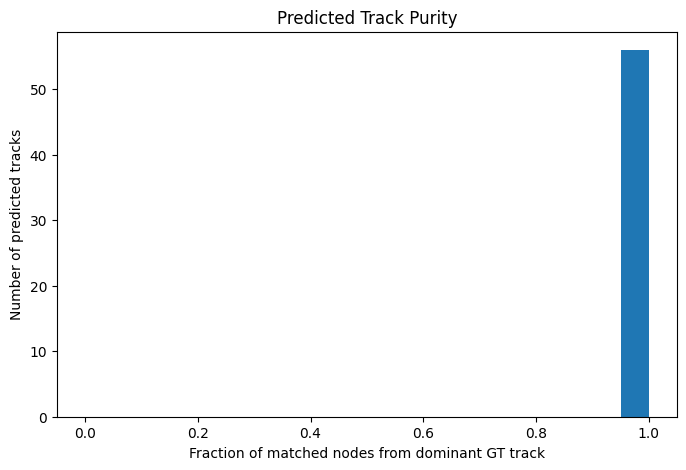

In [24]:
plt.figure(figsize=(8, 5))

valid_purity = track_purity_df[
    track_purity_df["track_purity"].notna()
]

plt.hist(
    valid_purity["track_purity"],
    bins=20,
    range=(0, 1),
)

plt.title("Predicted Track Purity")
plt.xlabel("Fraction of matched nodes from dominant GT track")
plt.ylabel("Number of predicted tracks")
plt.show()


In [25]:
detections_output_path = (
    "/kaggle/working/chapter28_detections.csv"
)

links_output_path = (
    "/kaggle/working/chapter28_links.csv"
)

tracks_output_path = (
    "/kaggle/working/chapter28_tracks.csv"
)

track_summary_output_path = (
    "/kaggle/working/chapter28_track_summary.csv"
)

all_detections_df.to_csv(
    detections_output_path,
    index=False,
)

all_links_df.to_csv(
    links_output_path,
    index=False,
)

tracks_df.to_csv(
    tracks_output_path,
    index=False,
)

track_summary_df.to_csv(
    track_summary_output_path,
    index=False,
)

print("Saved:", detections_output_path)
print("Saved:", links_output_path)
print("Saved:", tracks_output_path)
print("Saved:", track_summary_output_path)


Saved: /kaggle/working/chapter28_detections.csv
Saved: /kaggle/working/chapter28_links.csv
Saved: /kaggle/working/chapter28_tracks.csv
Saved: /kaggle/working/chapter28_track_summary.csv
